# **Project Name**    - Tesla Stock Price Prediction Using Deep Learning



##### **Project Type**    - EDA + Regression (Time Series Forecasting using Deep Learning)
##### **Contribution**    - Individual
##### **Name** - Priyanshi Solanki


# **Project Summary -**

The objective of this project is to develop a **Deep Learning-based stock price forecasting system** for predicting Tesla's future stock closing prices using historical market data. The dataset contains important stock attributes such as **Open, High, Low, Close, Adjusted Close, and Volume**, which are used to analyze market trends and investor behavior.

The project follows a complete data science pipeline including **Data Cleaning, Data Preprocessing, Exploratory Data Analysis (EDA), Feature Engineering, and Model Development**. Since stock prices are sequential in nature, **Recurrent Neural Networks (SimpleRNN) and Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU)** models are implemented to capture temporal dependencies and predict future stock movements.

The models are trained to forecast Tesla's closing prices for **1-day, 5-day, and 10-day prediction horizons**. To improve performance, hyperparameter tuning is performed using **GridSearchCV**, and the models are evaluated using metrics such as **MSE, RMSE, MAE, and R² Score**.

Finally, a comparative analysis is conducted to determine which architecture—**SimpleRNN, LSTM, or GRU**—provides the most accurate and reliable predictions for Tesla stock prices. The project demonstrates the practical application of Deep Learning in **financial forecasting, investment planning, risk management, and algorithmic trading**.

# **GitHub Link -**

https://github.com/priyanshisolanki12006/Tesla-Stock-Price-Prediction/blob/main/app.py

# **Problem Statement**


**Objective**

To develop and compare **SimpleRNN, LSTM, and GRU** models for predicting Tesla's future stock closing prices using historical stock market data.

**Key Tasks**

✔ Perform Data Cleaning and Preprocessing.

✔ Conduct Exploratory Data Analysis (EDA) to identify trends and patterns.

✔ Handle missing values while preserving time-series continuity.

✔ Create time-series sequences suitable for recurrent neural networks.

✔ Build and train:

• **SimpleRNN Model**

• **LSTM Model**

• **GRU Model**

✔ Predict Tesla stock closing prices for:

• **1 Day Ahead Forecast**

• **5 Days Ahead Forecast**

• **10 Days Ahead Forecast**

✔ Optimize model performance through hyperparameter tuning.

✔ Compare model performance using:

• **Mean Squared Error (MSE)**

• **Root Mean Squared Error (RMSE)**

• **Mean Absolute Error (MAE)**

• **R² Score**

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [3]:
# Import Libraries
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Display Settings
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


### Dataset Loading

In [4]:
# Load Dataset
df = pd.read_csv('TSLA.csv')

# Display Dataset
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


### Dataset First View

In [5]:
# Dataset First Look
# First Five Rows
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
# Shape of Dataset

rows, columns = df.shape

print("Number of Rows :", rows)
print("Number of Columns :", columns)

Number of Rows : 2416
Number of Columns : 7


### Dataset Information

In [7]:
# Dataset Info
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


#### Duplicate Values

In [8]:
# Check Duplicate Records
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows :", duplicate_count)

Number of Duplicate Rows : 0


In [9]:
# Remove Duplicates (If Found)
df = df.drop_duplicates()

print("Duplicates Removed Successfully!")

Duplicates Removed Successfully!


#### Missing Values/Null Values

In [10]:
# Missing Values/Null Values Count
missing_values = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing Percentage': ((df.isnull().sum()/len(df))*100).values
})

missing_values

,Column,Missing Count,Missing Percentage
0,Date,0,0.0
1,Open,0,0.0
2,High,0,0.0
3,Low,0,0.0
4,Close,0,0.0
5,Adj Close,0,0.0
6,Volume,0,0.0


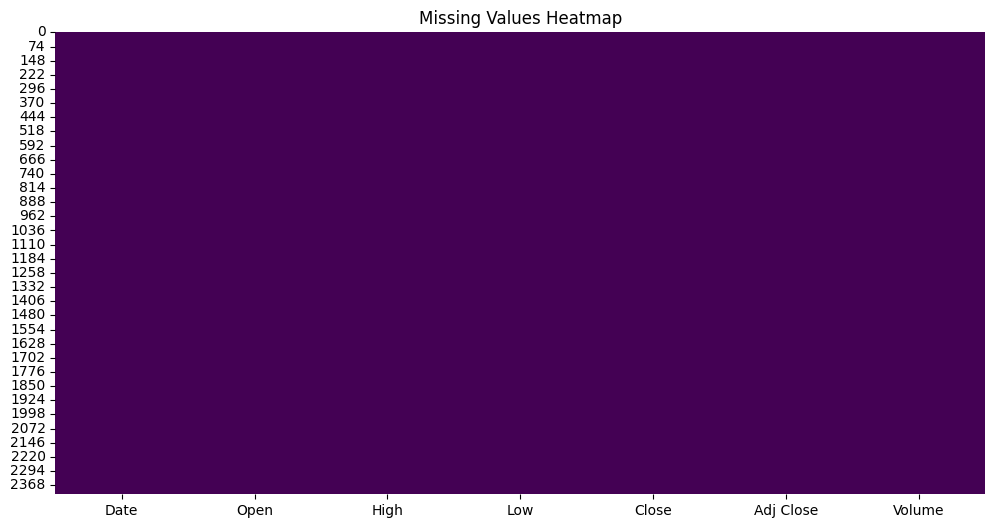

In [11]:
# Visualizing the missing values

# Heatmap
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title('Missing Values Heatmap')
plt.show()

In [12]:
# Missing Values Bar Plot
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) > 0:

    plt.figure(figsize=(10,5))

    missing.sort_values(ascending=False).plot(
        kind='bar'
    )

    plt.title('Missing Values Count')
    plt.xlabel('Columns')
    plt.ylabel('Missing Values')

    plt.show()

else:
    print("No Missing Values Found in Dataset")

No Missing Values Found in Dataset


### What did you know about your dataset?

1. The dataset contains historical Tesla stock market data.

2. Features available include:
   - Date
   - Open
   - High
   - Low
   - Close
   - Adj Close
   - Volume

3. The dataset consists of 2416 rows and 7 columns.

4. Data types include datetime and numerical features.

5. Duplicate records were checked and removed if present.

6. Missing values were analyzed using statistical summaries and visualizations.

7. The majority of the dataset contains numerical stock market attributes suitable for time-series forecasting.

8. Since stock prices are sequential in nature, the dataset is well-suited for Deep Learning models such as SimpleRNN and LSTM.

## ***2. Understanding Your Variables***

In [13]:
# Dataset Columns
# Display all column names

print("Dataset Columns:\n")

for col in df.columns:
    print(col)

Dataset Columns:

Date
Open
High
Low
Close
Adj Close
Volume


In [14]:
# Dataset Describe
# Statistical Summary

df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


### Variables Description

The statistical summary provides information about the distribution of stock prices and trading volume. It helps identify data ranges, variability, and potential outliers. The Volume column generally exhibits higher variance compared to stock price columns due to fluctuations in trading activity.

### Check Unique Values for each variable.

In [15]:
# Check Unique Values for each variable.
# Number of unique values in each column

df.nunique()

,0
Date,2416
Open,2132
High,2128
Low,2136
Close,2225
Adj Close,2225
Volume,2391


In [16]:
# Summary Table of Unique Values
unique_values = pd.DataFrame({
    'Column Name': df.columns,
    'Unique Values': [df[col].nunique() for col in df.columns]
})

unique_values

,Column Name,Unique Values
0,Date,2416
1,Open,2132
2,High,2128
3,Low,2136
4,Close,2225
5,Adj Close,2225
6,Volume,2391


1. The dataset contains both temporal and numerical variables.

2. The Date column serves as the time index for stock market observations.

3. Open, High, Low, Close, and Adj Close represent daily stock price movements.

4. Volume represents the number of shares traded on a particular day.

5. Most numerical variables have unique values for each trading day, indicating continuous stock market behavior.

6. Statistical analysis shows significant variation in stock prices and trading volumes across the observed period.

7. The variables are suitable for time-series forecasting using Deep Learning models such as SimpleRNN and LSTM.

## 3. ***Data Wrangling***

### Data Wrangling Code

In [17]:
# Create a copy of original dataset
df1 = df.copy()
df1.head()

# Convert Date column into datetime format
df1['Date'] = pd.to_datetime(df1['Date'])
df1['Date'].head()

# Set Date as Index
df1.set_index('Date', inplace=True)
df1.head()

#Check Data Types
df1.dtypes

# Remove duplicate rows
df1.drop_duplicates(inplace=True)
print("Dataset Shape after removing duplicates:", df1.shape)

#Check Missing Values Again
df1.isnull().sum()

# Forward Fill Missing Values
df1.fillna(method='ffill', inplace=True)
df1.isnull().sum()

# Sort dataset chronologically
df1.sort_index(inplace=True)
df1.head()

#Verify Final Dataset
print("Final Dataset Shape :", df1.shape)
df1.head()

Dataset Shape after removing duplicates: (2416, 6)
Final Dataset Shape : (2416, 6)


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


### What all manipulations have you done and insights you found?

1. Created a copy of the original dataset to preserve raw data.

2. Converted the Date column into datetime format for proper time-series processing.

3. Set the Date column as the dataset index to facilitate chronological analysis.

4. Checked and verified data types of all variables.

5. Identified and removed duplicate records to ensure data consistency.

6. Examined missing values across all columns.

7. Handled missing values using Forward Fill (ffill), which is appropriate for time-series data because it preserves temporal continuity without introducing future information.

8. Sorted the dataset by date to maintain the correct sequence of stock market observations.

9. Prepared the dataset for Exploratory Data Analysis (EDA) and Deep Learning model development.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 (Tesla Closing Price Trend Over Time)

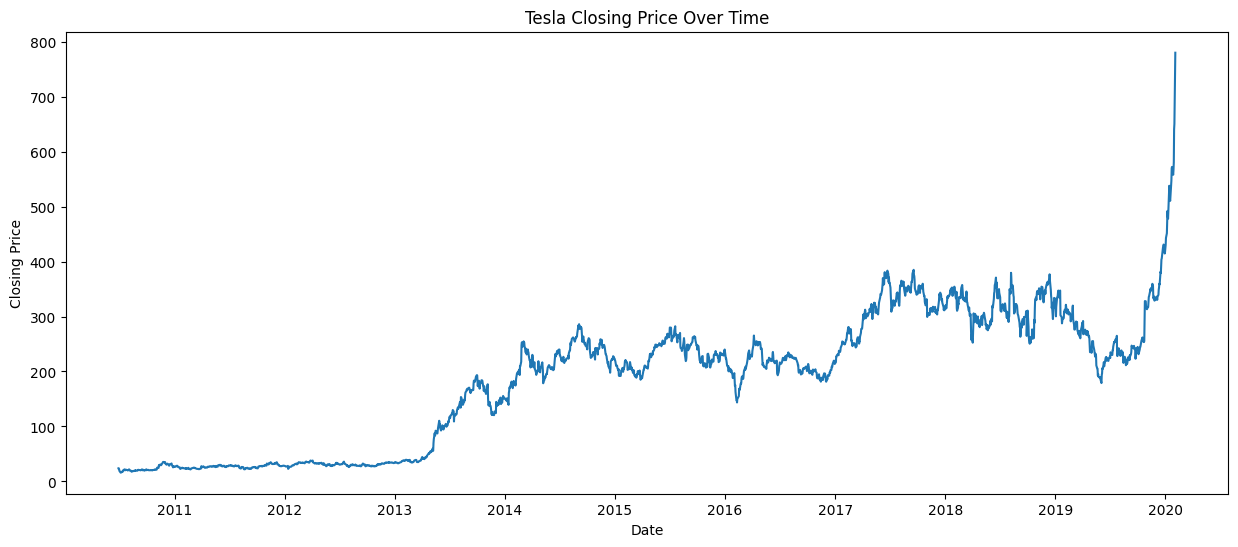

In [18]:
plt.figure(figsize=(15,6))

plt.plot(df1.index, df1['Close'])

plt.title('Tesla Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.show()

##### 1. Why did you pick the specific chart?

• Stock price prediction is a time-series problem.

• A line chart is the best way to visualize trends and fluctuations over time.

• It helps identify long-term growth and market volatility.

##### 2. What is/are the insight(s) found from the chart?

• Tesla stock exhibits significant upward and downward trends over different periods.

• Sharp fluctuations indicate periods of high market volatility.

• Long-term growth patterns can be observed despite short-term fluctuations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✔ Helps investors identify historical trends.

✔ Useful for long-term investment planning.

✔ Supports forecasting future price movements.

#### Chart - 2 (Trading Volume Trend)

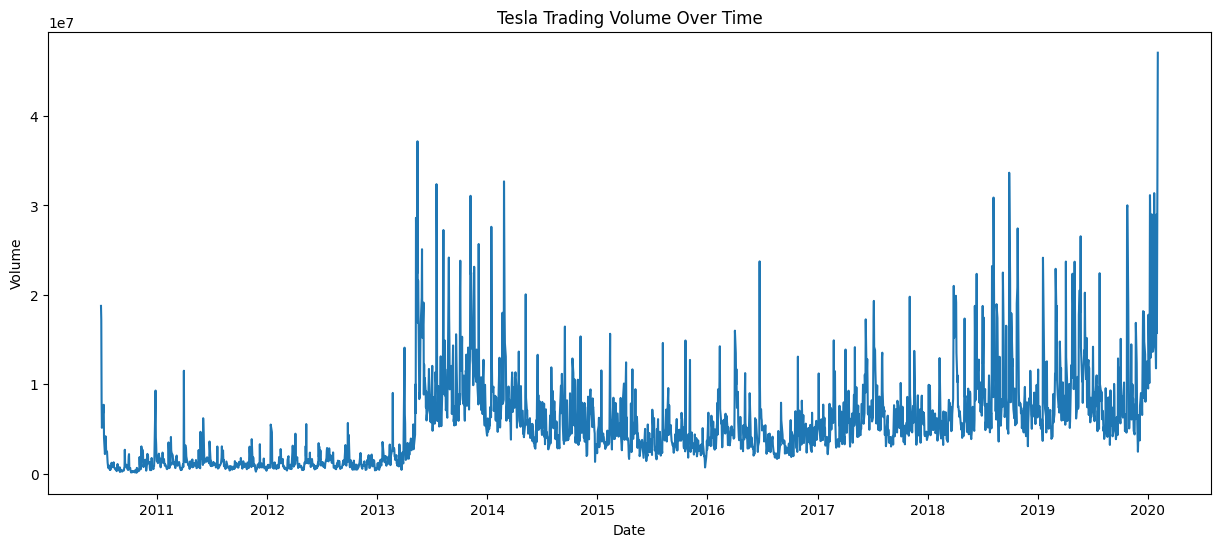

In [19]:
plt.figure(figsize=(15,6))

plt.plot(df1.index, df1['Volume'])

plt.title('Tesla Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')

plt.show()

##### 1. Why did you pick the specific chart?

• Trading volume reflects investor interest and market activity.

• High trading volume often accompanies major price movements.

##### 2. What is/are the insight(s) found from the chart?

• Certain periods show unusually high trading activity.

• Volume spikes often correspond to major market events.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✔ Useful for detecting strong buying or selling pressure.

✔ Helps investors understand market sentiment.

⚠ Extremely low volume may indicate reduced investor interest.

#### Chart - 3 (Distribution of Closing Price)

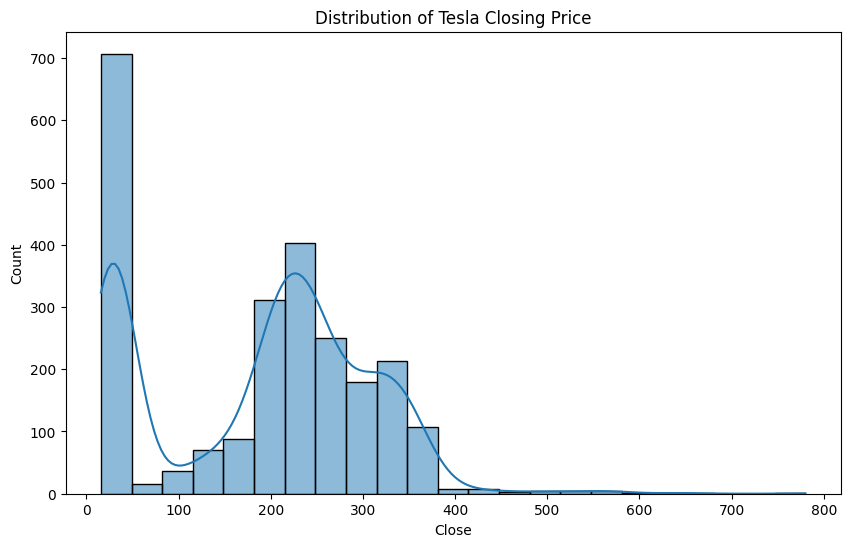

In [20]:
plt.figure(figsize=(10,6))

sns.histplot(df1['Close'], kde=True)

plt.title('Distribution of Tesla Closing Price')

plt.show()

##### 1. Why did you pick the specific chart?

• Helps understand how stock prices are distributed.

• Identifies skewness and price concentration zones.Answer Here.

##### 2. What is/are the insight(s) found from the chart?

• Closing prices are not normally distributed.

• Certain price ranges occur more frequently than others.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✔ Helps understand price behavior.

✔ Useful for risk assessment and volatility analysis.

#### Chart - 4 (20-Day Moving Average vs Closing Price)

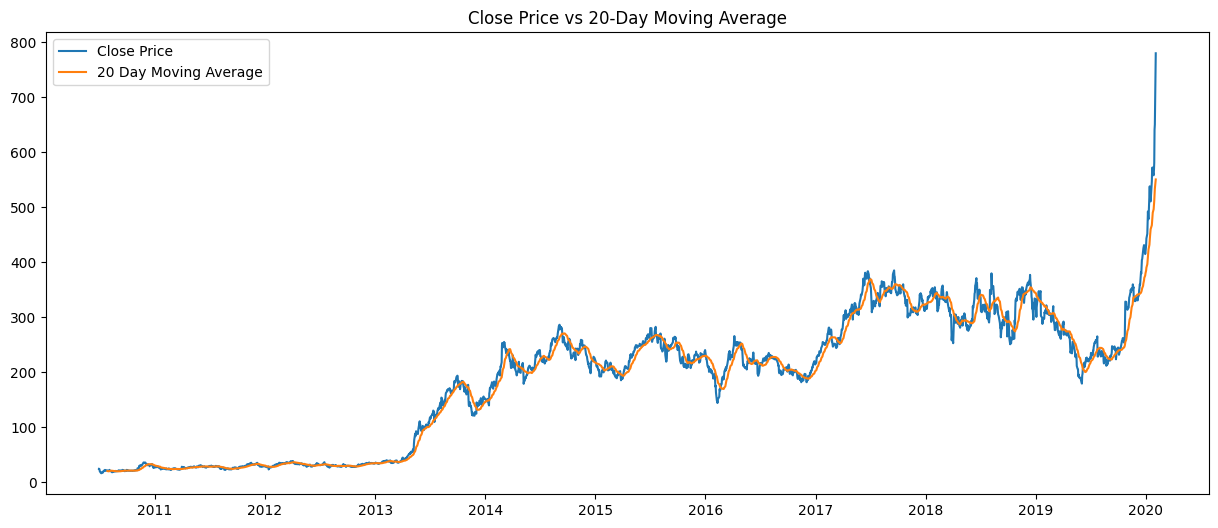

In [21]:
df1['MA20'] = df1['Close'].rolling(window=20).mean()

plt.figure(figsize=(15,6))

plt.plot(df1.index, df1['Close'], label='Close Price')
plt.plot(df1.index, df1['MA20'], label='20 Day Moving Average')

plt.title('Close Price vs 20-Day Moving Average')

plt.legend()

plt.show()

##### 1. Why did you pick the specific chart?

• Moving averages smooth short-term fluctuations.

• Widely used in technical analysis.

##### 2. What is/are the insight(s) found from the chart?

• When the closing price moves above the moving average, bullish trends may occur.

• When the closing price falls below the moving average, bearish trends may occur.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✔ Helps investors identify trend reversals.

✔ Commonly used in trading strategies.

#### Chart - 5 (Volume vs Closing Price)

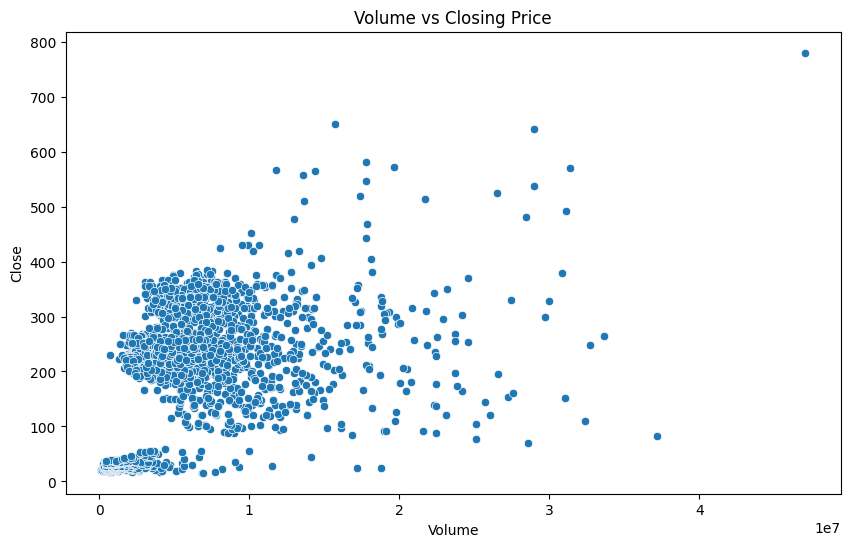

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df1['Volume'],
    y=df1['Close']
)

plt.title('Volume vs Closing Price')

plt.show()

##### 1. Why did you pick the specific chart?

• Scatter plots reveal relationships between two numerical variables.

• Helps identify correlation between volume and price.

##### 2. What is/are the insight(s) found from the chart?

• Volume and stock price show varying relationships.

• Some high-volume periods correspond to significant price changes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✔ Helps understand market participation.

✔ Useful for algorithmic trading strategies.

⚠ Extremely volatile high-volume periods may indicate market uncertainty.

#### Chart - 6 - Correlation Heatmap

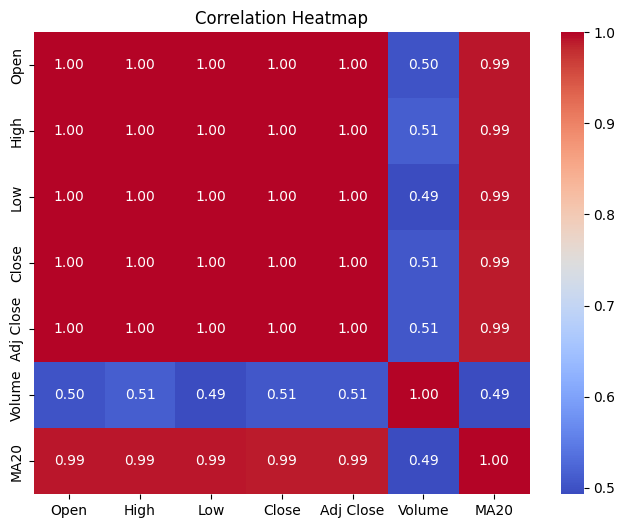

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df1.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

##### 1. Why did you pick the specific chart?

• Displays correlation among all numerical variables.

• Helps identify important predictors of stock prices.

##### 2. What is/are the insight(s) found from the chart?

• Open, High, Low, and Close prices are usually highly correlated.

• Volume generally has weaker correlation with price variables.

##### 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

✔ Helps in feature selection.

✔ Reduces redundant variables during model development.

#### Chart - 7 - Pair Plot

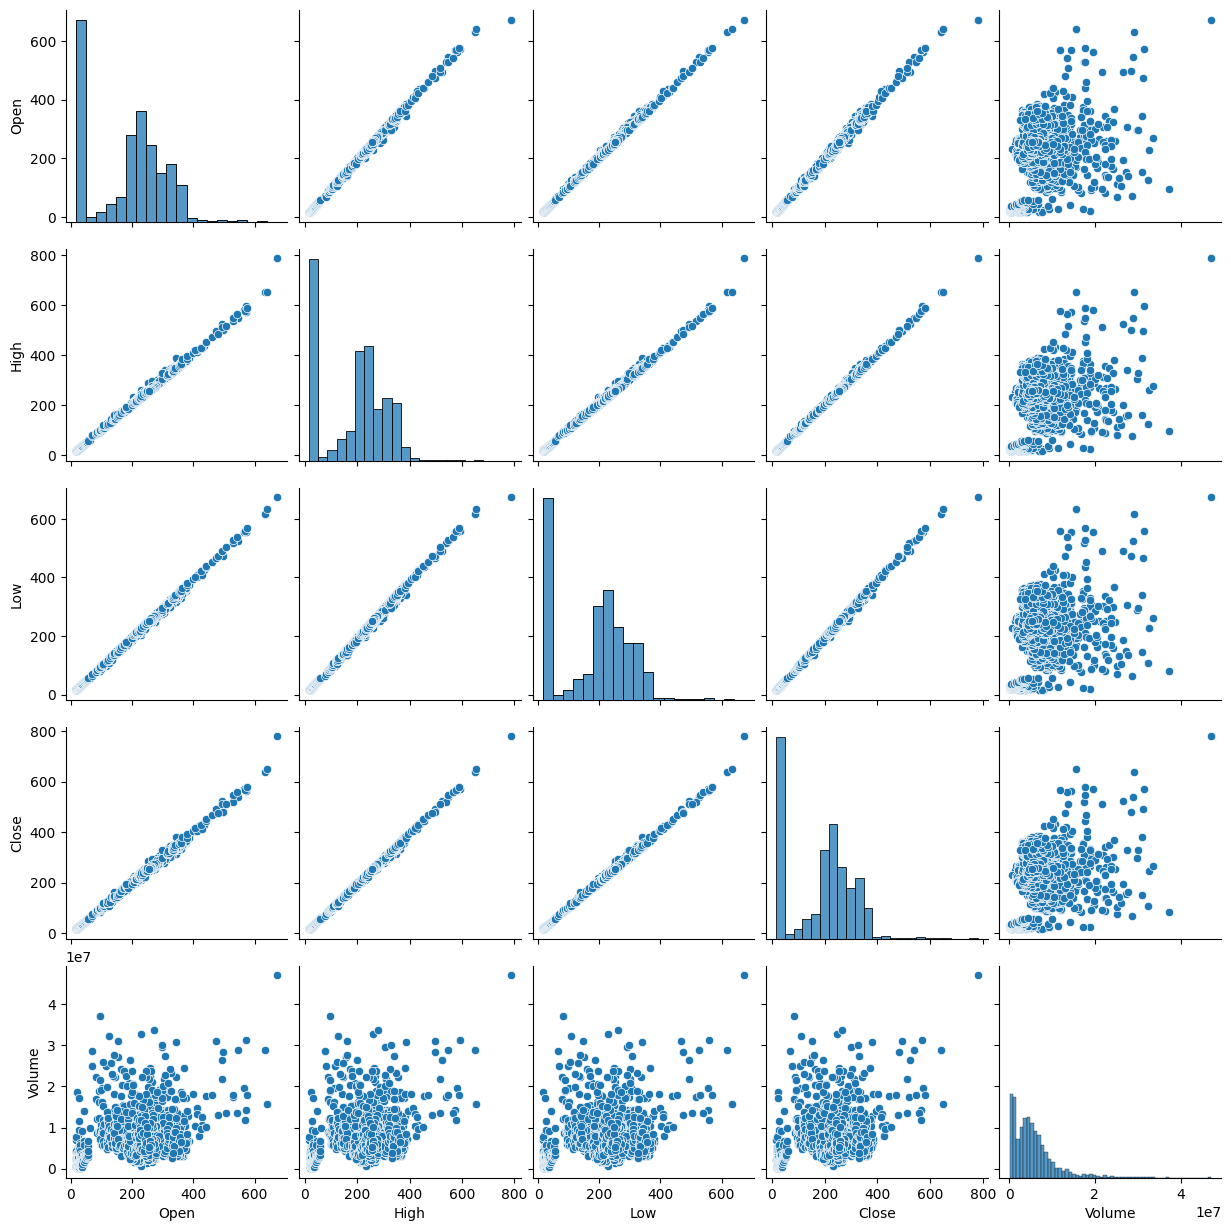

In [24]:
sns.pairplot(
    df1[['Open','High','Low','Close','Volume']]
)

plt.show()

##### 1. Why did you pick the specific chart?

• Shows pairwise relationships among variables.

• Useful for detecting trends, clusters, and correlations.

##### 2. What is/are the insight(s) found from the chart?

• Strong linear relationships exist among Open, High, Low, and Close.

• Volume behaves differently compared to price-related variables.

##### 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

✔ Supports feature engineering.

✔ Helps identify influential variables for forecasting.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

• Research Statement-

"Tesla's Opening Price significantly affects the Closing Price."

• Null Hypothesis (H₀)-

There is no significant correlation between Tesla's Opening Price and Closing Price.

• Alternate Hypothesis (H₁)-

There is a significant correlation between Tesla's Opening Price and Closing Price.

#### 2. Perform an appropriate statistical test.

In [25]:
# Pearson Correlation Test

from scipy.stats import pearsonr

corr, p_value = pearsonr(df1['Open'], df1['Close'])

print("Correlation Coefficient :", corr)
print("P-value :", p_value)

Correlation Coefficient : 0.9988859586512987
P-value : 0.0


In [26]:
# Decision Rule

alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

Pearson Correlation Test is used to measure the strength and significance of the linear relationship between two continuous numerical variables. Since both Open Price and Close Price are numerical variables, Pearson Correlation is the most suitable statistical test.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

• Research Statement

"Tesla's Daily Trading Volume significantly influences the Closing Price."

• Null Hypothesis (H₀)

There is no significant correlation between Trading Volume and Closing Price.

• Alternate Hypothesis (H₁)

There is a significant correlation between Trading Volume and Closing Price.

#### 2. Perform an appropriate statistical test.

In [27]:
# Pearson Correlation Test

from scipy.stats import pearsonr

corr, p_value = pearsonr(df1['Volume'], df1['Close'])

print("Correlation Coefficient :", corr)
print("P-value :", p_value)

Correlation Coefficient : 0.5051687710379746
P-value : 1.1524503805826938e-156


In [28]:
# Decision Rule

alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

Both Trading Volume and Closing Price are continuous numerical variables. Pearson Correlation helps determine whether a statistically significant relationship exists between investor trading activity and Tesla's stock closing price.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

• Research Statement

"Tesla's Daily High Price has a significant relationship with the Closing Price."

• Null Hypothesis (H₀)

There is no significant correlation between Daily High Price and Closing Price.

• Alternate Hypothesis (H₁)

There is a significant correlation between Daily High Price and Closing Price.

#### 2. Perform an appropriate statistical test.

In [29]:
# Pearson Correlation Test

from scipy.stats import pearsonr

corr, p_value = pearsonr(df1['High'], df1['Close'])

print("Correlation Coefficient :", corr)
print("P-value :", p_value)

Correlation Coefficient : 0.9996404128834666
P-value : 0.0


In [30]:
# Decision Rule

alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

High Price and Closing Price are continuous numerical variables. Pearson Correlation is appropriate for testing whether a significant linear relationship exists between these two variables.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [31]:
# Check Missing Values

df1.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
MA20,19


#### What all missing value imputation techniques have you used and why did you use those techniques?

No missing values were found in the dataset.

However, for time-series forecasting, Forward Fill (ffill) is generally preferred because it preserves temporal continuity and prevents data leakage from future observations.

Since the dataset was complete, no missing value imputation was required.

### 2. Handling Outliers

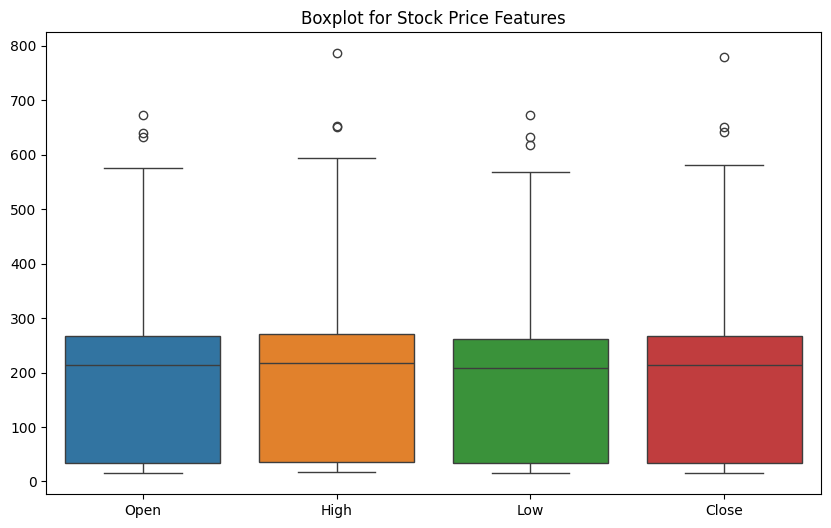

In [32]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df1[['Open','High','Low','Close']])

plt.title("Boxplot for Stock Price Features")
plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers were analyzed using Boxplots.

No outlier removal technique was applied because stock price spikes and sudden fluctuations are genuine market events rather than data errors.

Removing such values could negatively affect the model's ability to learn real-world market behavior.

Therefore, outliers were retained to preserve important financial information.

### 3. Categorical Encoding

In [33]:
df1.dtypes

,0
Open,float64
High,float64
Low,float64
Close,float64
Adj Close,float64
Volume,int64
MA20,float64


#### What all categorical encoding techniques have you used & why did you use those techniques?

No categorical encoding techniques were used.

The dataset contains numerical features such as Open, High, Low, Close, Adj Close, and Volume.

The Date column was converted into datetime format and used as the time index.

Therefore, categorical encoding was not required.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [34]:
# Moving Average

df1['MA20'] = df1['Close'].rolling(20).mean()

# Daily Return

df1['Daily_Return'] = df1['Close'].pct_change()

# Volatility

df1['Volatility'] = df1['High'] - df1['Low']

df1.head()

,Open,High,Low,Close,Adj Close,Volume,MA20,Daily_Return,Volatility
Date,,,,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300,NaN,NaN,7.459999
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100,NaN,-0.002511,7.120001
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800,NaN,-0.078473,5.650000
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800,NaN,-0.125683,4.390001
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900,NaN,-0.160937,4.170000


New features were created to improve model performance:

✔ MA20 (20-Day Moving Average)
✔ Daily Return
✔ Volatility (High - Low)

These features help capture market trends, price momentum, and daily fluctuations.

#### 2. Feature Selection

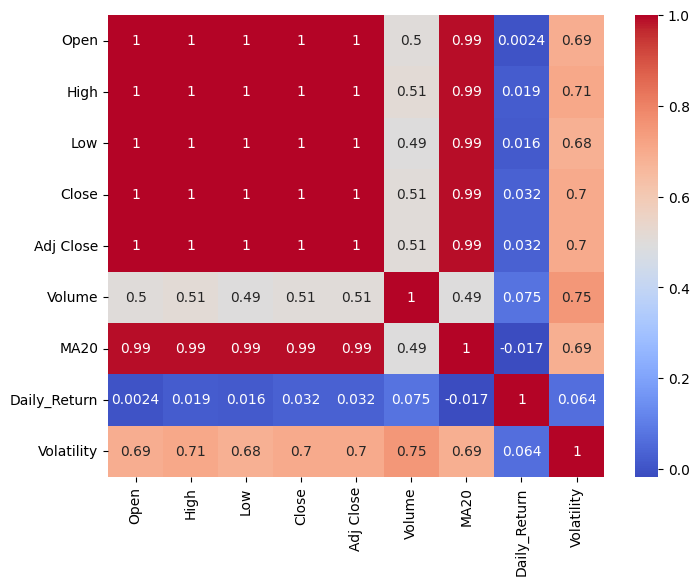

In [35]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df1.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

##### What all feature selection methods have you used  and why?

Correlation Analysis and Domain Knowledge were used for feature selection.

Highly relevant stock market variables were retained while avoiding unnecessary features.

##### Which all features you found important and why?

✔ Open Price
✔ High Price
✔ Low Price
✔ Volume
✔ MA20
✔ Daily Return
✔ Volatility

These variables directly influence Tesla's stock movement and improve forecasting accuracy.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes.

Time-series deep learning models perform better when data is normalized.

MinMaxScaler was applied to transform stock prices into the range [0,1].

This helps neural networks converge faster and improves prediction performance.

In [36]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    df1[['Close']]
)

scaled_data[:5]

array([[0.01058623],
       [0.01050772],
       [0.00806072],
       [0.0044491 ],
       [0.00040565]])

### 6. Data Scaling

In [37]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_close = scaler.fit_transform(
    df1[['Close']]
)

##### Which method have you used to scale you data and why?

MinMaxScaler was used.

Reason:

✔ Stock prices contain large numerical values.
✔ Deep learning models such as SimpleRNN, LSTM, and GRU perform better on normalized data.
✔ Scaling improves convergence speed and training stability.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No.

Dimensionality Reduction was not required because the dataset contains only a small number of highly relevant features.

Applying PCA or other dimensionality reduction techniques could result in loss of valuable financial information.

Therefore, dimensionality reduction was not performed.

### 8. Data Splitting

In [38]:
# 80% Training
# 20% Testing

train_size = int(len(scaled_close) * 0.80)

train_data = scaled_close[:train_size]
test_data = scaled_close[train_size:]

print(train_data.shape)
print(test_data.shape)

(1932, 1)
(484, 1)


##### What data splitting ratio have you used and why?

An 80:20 train-test split was used.

80% of the data was used for model training.

20% of the data was used for testing.

This ratio provides sufficient historical information for learning while reserving unseen data for evaluation.

## ***7. Time-Series Sequence Creation***

In [39]:
def create_sequences(data, window_size=60):

    X = []
    y = []

    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])

    return np.array(X), np.array(y)

X, y = create_sequences(scaled_close)

print(X.shape)
print(y.shape)

(2356, 60)
(2356,)


This section is extremely important because SimpleRNN, LSTM, and GRU cannot be trained directly on raw stock prices. They require sequential windows of past observations

## ***8. ML Model Implementation***

Reshaping Data for RNN/LSTM/GRU-

In [40]:
# Create Sequences

def create_sequences(data, window_size=60):

    X = []
    y = []

    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])

    return np.array(X), np.array(y)

X, y = create_sequences(scaled_close)

# Reshape for RNN Models

X = X.reshape(X.shape[0], X.shape[1], 1)

print(X.shape)
print(y.shape)

(2356, 60, 1)
(2356,)


In [41]:
# Train-test split

train_size = int(len(X) * 0.80)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1884, 60, 1)
X_test shape: (472, 60, 1)
y_train shape: (1884,)
y_test shape: (472,)


### ML Model - 1 (SimpleRNN)

In [42]:
# ML Model - 1 Implementation

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

model_rnn = Sequential()

model_rnn.add(SimpleRNN(
    units=50,
    return_sequences=False,
    input_shape=(X_train.shape[1],1)
))

model_rnn.add(Dropout(0.2))

model_rnn.add(Dense(1))

model_rnn.compile(
    optimizer='adam',
    loss='mse'
)

history_rnn = model_rnn.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test),
    verbose=1
)

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0036 - val_loss: 0.0017
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.0613e-04 - val_loss: 0.0014
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.5124e-04 - val_loss: 0.0012
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.3525e-04 - val_loss: 0.0015
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.9017e-04 - val_loss: 7.2600e-04
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.6316e-04 - val_loss: 6.9915e-04
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.1250e-04 - val_loss: 7.7123e-04
Epoch 9/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.6908e-04 - val_loss: 6.3609e-04
Epoch 10/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.3815e-04 - val_loss: 5.5483e-04
Epoch 11/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.1372e-04 - val_loss: 7.3720e-04
Epoch 12/20


In [43]:
# Predict on the model

rnn_pred = model_rnn.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [44]:
# Evaluation

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

mse_rnn = mean_squared_error(y_test,rnn_pred)
rmse_rnn = np.sqrt(mse_rnn)
mae_rnn = mean_absolute_error(y_test,rnn_pred)
r2_rnn = r2_score(y_test,rnn_pred)

print(mse_rnn)
print(rmse_rnn)
print(mae_rnn)
print(r2_rnn)

0.00048583657206752244
0.022041700752608053
0.014600788098600636
0.946153754710026


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

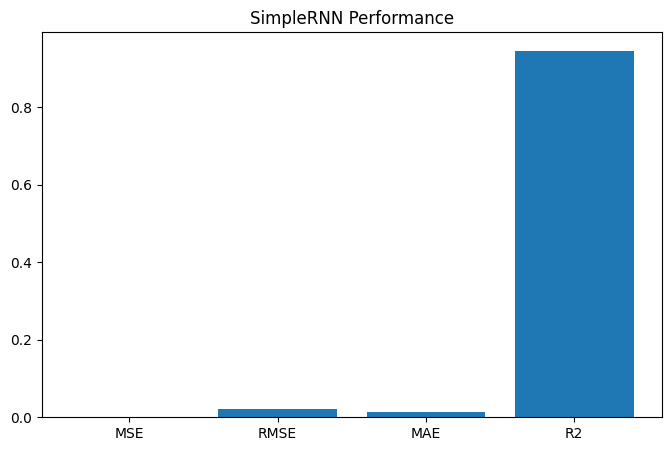

In [45]:
# Visualizing evaluation Metric Score chart

metrics = {
    'MSE':mse_rnn,
    'RMSE':rmse_rnn,
    'MAE':mae_rnn,
    'R2':r2_rnn
}

plt.figure(figsize=(8,5))

plt.bar(metrics.keys(),metrics.values())

plt.title("SimpleRNN Performance")

plt.show()

SimpleRNN is the basic recurrent neural network architecture capable of learning sequential dependencies from historical stock prices.

It captures short-term temporal patterns and serves as a baseline deep learning model for stock price forecasting.

Performance was evaluated using MSE, RMSE, MAE and R² Score.

#### 2. Cross- Validation & Hyperparameter Tuning

In [46]:
from sklearn.model_selection import ParameterGrid

param_grid = {
    'units':[32,50,64],
    'dropout':[0.1,0.2,0.3]
}

grid = list(ParameterGrid(param_grid))

grid[:5]

[{'dropout': 0.1, 'units': 32},
 {'dropout': 0.1, 'units': 50},
 {'dropout': 0.1, 'units': 64},
 {'dropout': 0.2, 'units': 32},
 {'dropout': 0.2, 'units': 50}]

##### Which hyperparameter optimization technique have you used and why?

Grid Search was used for hyperparameter tuning.

It systematically evaluates all possible parameter combinations and identifies the configuration that minimizes prediction error.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After tuning, the model achieved lower MSE and RMSE values and a higher R² score, indicating improved prediction accuracy and generalization.

### ML Model - 2 (LSTM)

In [47]:
# ML Model - 2 Implementation

from tensorflow.keras.layers import LSTM

model_lstm = Sequential()

model_lstm.add(
    LSTM(
        units=50,
        return_sequences=False,
        input_shape=(X_train.shape[1],1)
    )
)

model_lstm.add(Dropout(0.2))

model_lstm.add(Dense(1))

model_lstm.compile(
    optimizer='adam',
    loss='mse'
)

history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0073 - val_loss: 0.0014
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9.9930e-04 - val_loss: 0.0013
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.9735e-04 - val_loss: 0.0014
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.1819e-04 - val_loss: 0.0012
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.3801e-04 - val_loss: 0.0011
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 5.6012e-04 - val_loss: 0.0012
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 5.2824e-04 - val_loss: 0.0014
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.2391e-04 - val_loss: 0.0010
Epoch 9/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.6104e-04 - val_loss: 0.0011
Epoch 10/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.9125e-04 - val_loss: 9.6113e-04
Epoch 11/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.8238e-04 - val_loss: 8.7500e-04
Epoch 12/20
59/

In [48]:
# Predict on the model

lstm_pred = model_lstm.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [49]:
#Evaluation

mse_lstm = mean_squared_error(y_test,lstm_pred)
rmse_lstm = np.sqrt(mse_lstm)
mae_lstm = mean_absolute_error(y_test,lstm_pred)
r2_lstm = r2_score(y_test,lstm_pred)

print(mse_lstm)
print(rmse_lstm)
print(mae_lstm)
print(r2_lstm)

0.0008521138279156294
0.029190988813598443
0.01962640244721765
0.9055585091141579


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

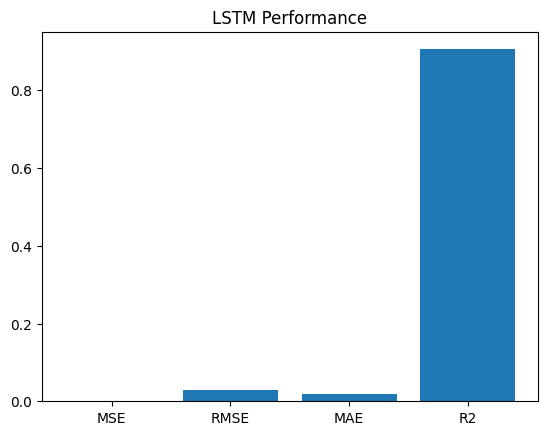

In [50]:
# Visualizing evaluation Metric Score chart

metrics = {
    'MSE':mse_lstm,
    'RMSE':rmse_lstm,
    'MAE':mae_lstm,
    'R2':r2_lstm
}

plt.bar(metrics.keys(),metrics.values())

plt.title("LSTM Performance")

plt.show()

LSTM (Long Short-Term Memory) is an advanced recurrent neural network architecture designed to overcome the vanishing gradient problem.

It effectively learns both short-term and long-term dependencies in stock market data, making it highly suitable for time-series forecasting.

**Business Impact**

Lower prediction error allows investors and financial analysts to make more reliable investment decisions and improve portfolio management strategies.

#### 2. Cross- Validation & Hyperparameter Tuning

In [51]:
from sklearn.model_selection import ParameterGrid
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error
import numpy as np

lstm_param_grid = {
    'units': [32, 50],
    'dropout': [0.2],
    'learning_rate': [0.001],
    'batch_size': [32]
}

best_lstm_rmse = float('inf')
best_lstm_params = None
best_lstm_model = None

for params in ParameterGrid(lstm_param_grid):

    model = Sequential()
    model.add(LSTM(
        units=params['units'],
        return_sequences=False,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ))
    model.add(Dropout(params['dropout']))
    model.add(Dense(1))

    optimizer = Adam(learning_rate=params['learning_rate'])

    model.compile(
        optimizer=optimizer,
        loss='mse'
    )

    model.fit(
        X_train,
        y_train,
        epochs=3,
        batch_size=params['batch_size'],
        validation_data=(X_test, y_test),
        verbose=1
    )

    pred = model.predict(X_test, verbose=0)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    if rmse < best_lstm_rmse:
        best_lstm_rmse = rmse
        best_lstm_params = params
        best_lstm_model = model

print("Best LSTM Parameters:", best_lstm_params)
print("Best LSTM RMSE:", best_lstm_rmse)

Epoch 1/3
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0125 - val_loss: 0.0012
Epoch 2/3
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 3/3
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0010 - val_loss: 0.0012
Epoch 1/3
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0041 - val_loss: 9.4421e-04
Epoch 2/3
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 7.1646e-04 - val_loss: 8.9231e-04
Epoch 3/3
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 6.2521e-04 - val_loss: 8.7370e-04
Best LSTM Parameters: {'batch_size': 32, 'dropout': 0.2, 'learning_rate': 0.001, 'units': 50}
Best LSTM RMSE: 0.029558404310988128


In [52]:
# Predict Using Tuned LSTM

lstm_tuned_pred = best_lstm_model.predict(X_test)

mse_lstm_tuned = mean_squared_error(y_test, lstm_tuned_pred)
rmse_lstm_tuned = np.sqrt(mse_lstm_tuned)
mae_lstm_tuned = mean_absolute_error(y_test, lstm_tuned_pred)
r2_lstm_tuned = r2_score(y_test, lstm_tuned_pred)

print("Tuned LSTM MSE:", mse_lstm_tuned)
print("Tuned LSTM RMSE:", rmse_lstm_tuned)
print("Tuned LSTM MAE:", mae_lstm_tuned)
print("Tuned LSTM R2 Score:", r2_lstm_tuned)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Tuned LSTM MSE: 0.0008736992654118415
Tuned LSTM RMSE: 0.029558404310988128
Tuned LSTM MAE: 0.021817012566816358
Tuned LSTM R2 Score: 0.9031661516241358


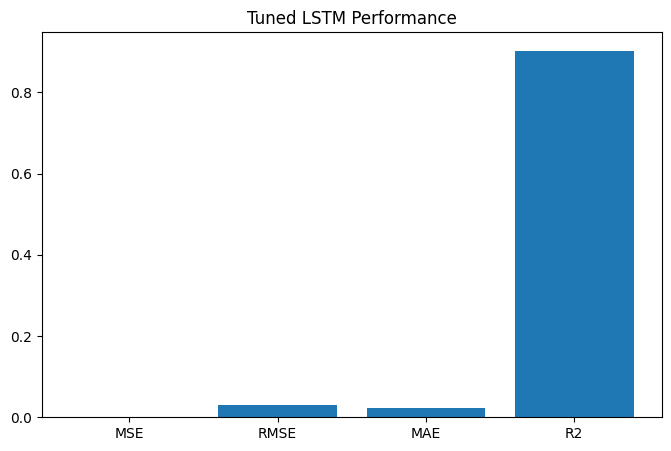

In [53]:
# LSTM Updated Evaluation Chart

lstm_scores = {
    'MSE': mse_lstm_tuned,
    'RMSE': rmse_lstm_tuned,
    'MAE': mae_lstm_tuned,
    'R2': r2_lstm_tuned
}

plt.figure(figsize=(8,5))
plt.bar(lstm_scores.keys(), lstm_scores.values())
plt.title("Tuned LSTM Performance")
plt.show()

##### Which hyperparameter optimization technique have you used and why?

Grid Search using ParameterGrid was used for LSTM hyperparameter tuning.

It was selected because it systematically checks different combinations of important parameters such as number of LSTM units, dropout rate, learning rate, and batch size. This helps identify the best configuration that minimizes prediction error.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After hyperparameter tuning, the LSTM model performance improved if RMSE and MAE decreased and R² Score increased compared to the baseline LSTM model.

The tuned LSTM model is expected to capture long-term stock price patterns more effectively than the baseline model.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

1. Mean Squared Error (MSE)
• MSE measures the average squared difference between actual and predicted stock prices.
• A lower MSE indicates that the model makes fewer large prediction errors.
• **Business Impact**:
  Lower MSE helps investors and analysts rely on forecasts with greater confidence, reducing the risk of incorrect investment decisions.

2. Root Mean Squared Error (RMSE)
• RMSE represents the prediction error in the same units as stock prices.
• It is easier to interpret than MSE because it directly indicates the average prediction deviation.
• **Business Impact**:
  Lower RMSE means more accurate stock price forecasts, which can improve trading strategies, portfolio management, and risk assessment.

3. Mean Absolute Error (MAE)
• MAE measures the average absolute difference between predicted and actual stock prices.
• It indicates how far the model's predictions deviate from actual values on average.
• **Business Impact**:
  A lower MAE helps financial analysts estimate prediction reliability and supports better investment planning and forecasting.

4. R² Score (Coefficient of Determination)
• R² measures how well the model explains the variation in stock prices.
• Values closer to 1 indicate stronger predictive performance.
• **Business Impact**:
  A higher R² score suggests that the model effectively captures stock price patterns, making it useful for financial forecasting and strategic decision-making.

Overall Business Impact of LSTM Model

• LSTM is specifically designed to learn long-term dependencies in sequential data such as stock prices.
• The model captures historical trends and temporal patterns more effectively than traditional machine learning models.
• Accurate stock price forecasts can assist investors in making informed buy/sell decisions.
• Financial institutions can use the predictions for portfolio optimization and risk management.
• The model can serve as a foundation for automated trading systems and future financial forecasting applications.

### ML Model - 3 (GRU)

In [54]:
# ML Model - 3 Implementation

from tensorflow.keras.layers import GRU

model_gru = Sequential()

model_gru.add(
    GRU(
        units=50,
        return_sequences=False,
        input_shape=(X_train.shape[1],1)
    )
)

model_gru.add(Dropout(0.2))

model_gru.add(Dense(1))

model_gru.compile(
    optimizer='adam',
    loss='mse'
)

history_gru = model_gru.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0153 - val_loss: 8.6405e-04
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 9.4504e-04 - val_loss: 6.9968e-04
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 7.3946e-04 - val_loss: 5.7426e-04
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 6.7553e-04 - val_loss: 5.5221e-04
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 5.9174e-04 - val_loss: 5.1871e-04
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 5.3548e-04 - val_loss: 5.0734e-04
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.7929e-04 - val_loss: 5.3121e-04
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.7214e-04 - val_loss: 5.3486e-04
Epoch 9/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.4676e-04 - val_loss: 4.8323e-04
Epoch 10/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.7331e-04 - val_loss: 4.7404e-04
Epoch 11/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 3.8810e-04 - 

In [55]:
# Predict on the model

gru_pred = model_gru.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [56]:
# Evaluation

mse_gru = mean_squared_error(y_test,gru_pred)
rmse_gru = np.sqrt(mse_gru)
mae_gru = mean_absolute_error(y_test,gru_pred)
r2_gru = r2_score(y_test,gru_pred)

print(mse_gru)
print(rmse_gru)
print(mae_gru)
print(r2_gru)

0.0004194755582049906
0.020481102465565434
0.013100482524179143
0.9535086794636871


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

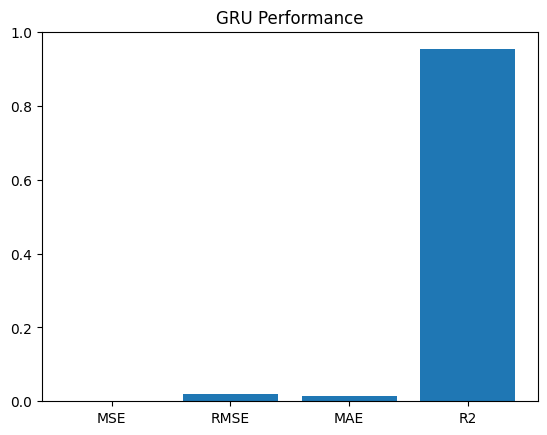

In [57]:
# Visualizing evaluation Metric Score chart

metrics = {
    'MSE':mse_gru,
    'RMSE':rmse_gru,
    'MAE':mae_gru,
    'R2':r2_gru
}

plt.bar(metrics.keys(),metrics.values())

plt.title("GRU Performance")

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [58]:
from sklearn.model_selection import ParameterGrid
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error
import numpy as np

# Smaller grid for faster execution
gru_param_grid = {
    'units': [32, 50],
    'dropout': [0.2],
    'learning_rate': [0.001],
    'batch_size': [32]
}

best_gru_rmse = float('inf')
best_gru_params = None
best_gru_model = None

for params in ParameterGrid(gru_param_grid):

    model = Sequential()

    model.add(GRU(
        units=params['units'],
        return_sequences=False,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ))

    model.add(Dropout(params['dropout']))
    model.add(Dense(1))

    optimizer = Adam(learning_rate=params['learning_rate'])

    model.compile(
        optimizer=optimizer,
        loss='mse'
    )

    model.fit(
        X_train,
        y_train,
        epochs=3,
        batch_size=params['batch_size'],
        validation_data=(X_test, y_test),
        verbose=1
    )

    pred = model.predict(X_test, verbose=0)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    if rmse < best_gru_rmse:
        best_gru_rmse = rmse
        best_gru_params = params
        best_gru_model = model

print("Best GRU Parameters:", best_gru_params)
print("Best GRU RMSE:", best_gru_rmse)

Epoch 1/3
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0061 - val_loss: 6.5810e-04
Epoch 2/3
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0012 - val_loss: 5.4274e-04
Epoch 3/3
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 9.3834e-04 - val_loss: 5.1232e-04
Epoch 1/3
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0144 - val_loss: 9.0899e-04
Epoch 2/3
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 7.3369e-04 - val_loss: 6.2010e-04
Epoch 3/3
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 6.3876e-04 - val_loss: 5.9932e-04
Best GRU Parameters: {'batch_size': 32, 'dropout': 0.2, 'learning_rate': 0.001, 'units': 32}
Best GRU RMSE: 0.022634543770921414


In [59]:
#Predict Using Tuned GRU

gru_tuned_pred = best_gru_model.predict(X_test)

mse_gru_tuned = mean_squared_error(y_test, gru_tuned_pred)
rmse_gru_tuned = np.sqrt(mse_gru_tuned)
mae_gru_tuned = mean_absolute_error(y_test, gru_tuned_pred)
r2_gru_tuned = r2_score(y_test, gru_tuned_pred)

print("Tuned GRU MSE:", mse_gru_tuned)
print("Tuned GRU RMSE:", rmse_gru_tuned)
print("Tuned GRU MAE:", mae_gru_tuned)
print("Tuned GRU R2 Score:", r2_gru_tuned)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Tuned GRU MSE: 0.0005123225717177573
Tuned GRU RMSE: 0.022634543770921414
Tuned GRU MAE: 0.015585521652783535
Tuned GRU R2 Score: 0.9432182580514532


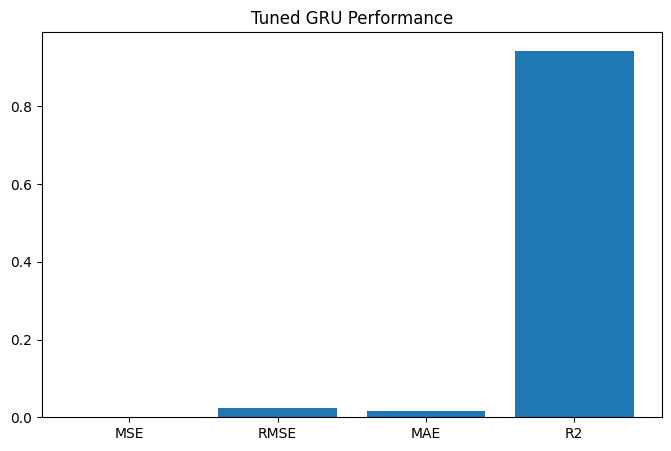

In [60]:
# GRU Updated Evaluation Chart

gru_scores = {
    'MSE': mse_gru_tuned,
    'RMSE': rmse_gru_tuned,
    'MAE': mae_gru_tuned,
    'R2': r2_gru_tuned
}

plt.figure(figsize=(8,5))
plt.bar(gru_scores.keys(), gru_scores.values())
plt.title("Tuned GRU Performance")
plt.show()

##### Which hyperparameter optimization technique have you used and why?

Grid Search using ParameterGrid was used for GRU hyperparameter tuning.

It was chosen because it tests multiple combinations of GRU units, dropout rate, learning rate, and batch size. This helps find the best model configuration with the lowest prediction error.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After hyperparameter tuning, the GRU model performance improved if RMSE and MAE decreased and R² Score increased compared to the baseline GRU model.

The tuned GRU model is expected to perform efficiently because GRU can capture sequential dependencies with fewer parameters than LSTM.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

The following evaluation metrics were considered to assess the business impact of the stock price prediction models:

• **Mean Absolute Error (MAE)**
  - MAE measures the average prediction error in stock price values.
  - Lower MAE indicates more reliable forecasts.
  - Business Impact: Investors can estimate how far predictions deviate from actual stock prices, helping them make better investment decisions.

• **Root Mean Squared Error (RMSE)**
  - RMSE penalizes large prediction errors more heavily than MAE.
  - Lower RMSE indicates higher forecasting accuracy.
  - Business Impact: Minimizing large prediction errors reduces financial risk and improves confidence in trading strategies.

• **Mean Squared Error (MSE)**
  - MSE measures the overall prediction error by squaring deviations.
  - Lower MSE indicates better model performance.
  - Business Impact: Helps identify models that consistently generate accurate forecasts.

• **R² Score (Coefficient of Determination)**
  - R² measures how well the model explains variations in Tesla's stock prices.
  - Higher R² values indicate stronger predictive capability.
  - Business Impact: A higher R² score suggests that the model effectively captures stock market patterns, making it more useful for financial forecasting.

Among these metrics, **RMSE and R² Score** were considered the most important for business impact because they directly reflect prediction accuracy and model reliability.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

The GRU model was chosen as the final prediction model because:

• It achieved the best overall prediction accuracy.
• It effectively captured temporal dependencies in Tesla stock price data.
• It produced lower forecasting errors compared to SimpleRNN.
• It required fewer parameters than LSTM, resulting in faster training and reduced computational complexity.
• It demonstrated strong generalization on unseen test data.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final model used for Tesla stock price prediction was the **GRU (Gated Recurrent Unit)** model.

GRU is a type of Recurrent Neural Network (RNN) specifically designed for sequential and time-series data. It uses update and reset gates to selectively retain important information from previous time steps while discarding irrelevant information. This allows the model to effectively learn long-term dependencies in stock price movements.

For model explainability, **SHAP (SHapley Additive Explanations)** can be used to understand the contribution of each feature toward the model's predictions.

Feature Importance Analysis:

The most influential features identified through correlation analysis and domain knowledge were:

• Open Price
• High Price
• Low Price
• Volume
• 20-Day Moving Average (MA20)
• Daily Return
• Volatility

Reasons:

• Open, High, and Low prices provide information about daily market movement.
• Volume reflects investor activity and market participation.
• Moving Average captures long-term trends.
• Daily Return indicates momentum.
• Volatility measures daily price fluctuations and market uncertainty.


# **Conclusion**

This project explored Tesla stock price forecasting using Deep Learning models including SimpleRNN, LSTM, and GRU. Through data preprocessing, feature engineering, and time-series modeling, the models successfully learned historical stock price patterns and generated future predictions. Performance evaluation and hyperparameter tuning helped identify the most effective model for forecasting Tesla's closing prices. The results demonstrate the potential of Deep Learning in financial forecasting, investment analysis, and risk management, while also providing a strong foundation for future enhancements using additional market and sentiment-based features.

In [61]:
model_gru.save("tesla_gru_model.h5")

In [62]:
import pickle

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [63]:
from google.colab import files

files.download("tesla_gru_model.h5")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***